# High-z Example 08: Reproducing Table 4 — Omega Values

**EPS Research — High-z Kinematic Corpus Z1**

This example reproduces Table 4 from Flynn (2026) arXiv:2605.25339:
omega values for all 8 tier-1 rotators computed from boundary points.

All 8 values are negative (median -13.05 rad/Gyr), contrasting
with positive values at z=0 (SPARC mean +7.06 rad/Gyr).

**Reference:** Flynn (2026), arXiv:2605.25339

**Corpus:** Flynn (2026), Zenodo DOI: 10.5281/zenodo.20369285  
**arXiv:** 2605.25339  
**Source:** Jones et al. (2021), MNRAS 507, 3540; Le Fevre et al. (2020)  
**Dependencies:** Python 3, numpy, matplotlib

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt

with open('high_z_kinematic_corpus_Z1.json') as f:
    corpus = json.load(f)

galaxies  = corpus['galaxies']
rotators  = [g for g in galaxies if g.get('is_rotator') and g.get('quality_tier')==1]
print(f"Total galaxies: {len(galaxies)}")
print(f"Tier-1 rotators: {len(rotators)}")


Total galaxies: 31
Tier-1 rotators: 8


In [2]:
results = []
for g in sorted(rotators, key=lambda x: x['redshift']):
    d  = g['data']
    R1, V1 = d[0]['R_kpc'],  d[0]['Vrot_kms']
    R2, V2 = d[-1]['R_kpc'], d[-1]['Vrot_kms']
    omega  = (V2/R2 - V1/R1) * (R1/R2)**1.5
    results.append({'galaxy': g['galaxy'], 'z': g['redshift'],
                    'R2': R2, 'V2': V2, 'omega': omega,
                    'n_rings': len(d)})

omegas = [r['omega'] for r in results]
print(f"{'='*60}")
print(f"Table 4 Reproduction — Z1 Omega Values")
print(f"{'='*60}")
print(f"{'Galaxy':<20} {'z':>7} {'R2':>6} {'V2':>8} {'omega':>10} {'N':>4}")
print('-'*60)
for r in results:
    print(f"{r['galaxy']:<20} {r['z']:>7.4f} {r['R2']:>6.2f} "
          f"{r['V2']:>8.2f} {r['omega']:>10.3f} {r['n_rings']:>4}")
print('-'*60)
print(f"Median omega: {np.median(omegas):.3f} rad/Gyr")
print(f"All negative: {all(o < 0 for o in omegas)}")
print(f"\nPublished (Flynn 2026): median = -13.05 rad/Gyr")
print(f"SPARC z=0 mean: +7.06 rad/Gyr (Flynn & Cannaliato 2025)")

Table 4 Reproduction — Z1 Omega Values
Galaxy                     z     R2       V2      omega    N
------------------------------------------------------------
J0817                 4.2605   2.84   252.09    -33.222    2
CG32                  4.4105   3.50   115.04    -13.046    2
DC396844              4.5424   3.75    80.42    -14.484    2
VC5110377875          4.5506   3.84   102.85    -12.733    2
DC881725              4.5778   3.44    62.07    -13.046    2
DC552206              5.5016   5.53   172.84     -2.964    3
HZ9                   5.5413   2.68   176.63    -20.143    3
DC494057              5.5446   3.13    80.31     -9.531    2
------------------------------------------------------------
Median omega: -13.046 rad/Gyr
All negative: True

Published (Flynn 2026): median = -13.05 rad/Gyr
SPARC z=0 mean: +7.06 rad/Gyr (Flynn & Cannaliato 2025)


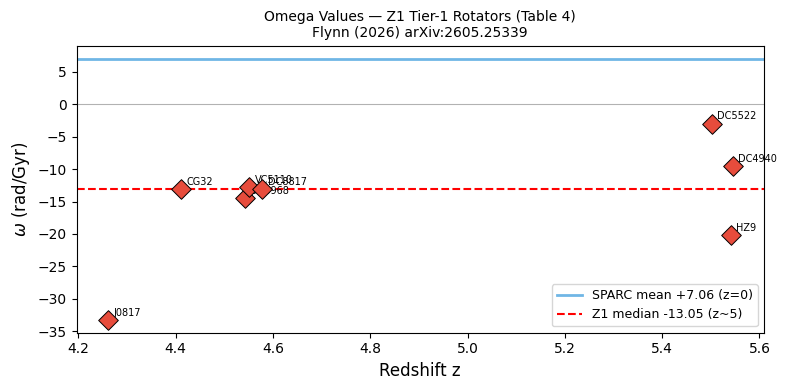

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
zs = [r['z'] for r in results]
ax.scatter(zs, omegas, s=100, color='#e74c3c', zorder=5,
           marker='D', edgecolors='k', linewidths=0.7)
for r in results:
    ax.annotate(r['galaxy'][:6], (r['z'], r['omega']),
                textcoords='offset points', xytext=(4, 3), fontsize=7)
ax.axhline(0,    color='black', ls='-',  lw=0.8, alpha=0.3)
ax.axhline(7.06, color='#3498db', ls='-', lw=2, alpha=0.7,
           label='SPARC mean +7.06 (z=0)')
ax.axhline(-13.05, color='red', ls='--', lw=1.5,
           label='Z1 median -13.05 (z~5)')
ax.set_xlabel('Redshift z', fontsize=12)
ax.set_ylabel(r'$\omega$ (rad/Gyr)', fontsize=12)
ax.set_title('Omega Values — Z1 Tier-1 Rotators (Table 4)\n'
             'Flynn (2026) arXiv:2605.25339', fontsize=10)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('hz08_omega_table.png', dpi=150, bbox_inches='tight')
plt.show()